# General setup

In [1]:
# Imports
import argparse
import re
import json
import warnings
import numpy as np
from modules.CHILI import CHILI
from modules.net import SCVAE
from torch_geometric.loader import DataLoader
import torch
from torch.utils.data import TensorDataset
import datetime
import pathlib
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ase import Atoms
from ase.io import write
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from modules.loss_functions import weighted_MSELoss, weighted_CrossEntropyLoss
from copy import deepcopy

warnings.filterwarnings("ignore")

In [2]:
# Functions
def create_cif(cell_params, cell_positions, cell_atoms, filename, prediction=True, composition=None, simplified_atom_identities=False):
    """
    Create a CIF file from the cell parameters, positions and atoms
    """
    if prediction:
        # Find argmax of atoms
        cell_atoms = np.argmax(cell_atoms, axis=1)

    # Remove atoms with atom number 0
    cell_positions = cell_positions[cell_atoms != 0]
    cell_atoms = cell_atoms[cell_atoms != 0]
    
    # Remove atoms not in the unit cell
    cell_atoms = cell_atoms[(cell_positions[:,0] < 0.95) & (cell_positions[:,1] < 0.95) & (cell_positions[:,2] < 0.95)]
    cell_positions = cell_positions[(cell_positions[:,0] < 0.95) & (cell_positions[:,1] < 0.95) & (cell_positions[:,2] < 0.95)]
    
    
    if simplified_atom_identities:
        cell_atoms = np.where(cell_atoms == 1, 8, cell_atoms)
        cell_atoms = np.where(cell_atoms == 2, 26, cell_atoms)
    
    # Create Atoms object
    atoms = Atoms(cell_atoms, scaled_positions=cell_positions, cell=cell_params)

    if not composition:
        composition = str(atoms.symbols)

    # Write CIF
    write(filename + f'.cif', images=atoms, format='cif') # _{composition}

    if not prediction:
        return composition
    return None

In [3]:
# Setup
model_path = './models/Combined_data_beta_annealing_3d_latentMSE_biggerDecoder/'
model_name = 'best_model_annealed.pth'
setup_json_path = f'{model_path}setup_json.json'
with open(setup_json_path, 'r') as setup_json_file:
    setup_json = json.load(setup_json_file)

# Make prediction folders
experimental_folder = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/experimental_predictions'
pathlib.Path(experimental_folder).mkdir(parents=True, exist_ok=True)

interpolation_folder = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/interpolation_predictions'
pathlib.Path(interpolation_folder).mkdir(parents=True, exist_ok=True)

sample_folder = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/sample_predictions'
pathlib.Path(sample_folder).mkdir(parents=True, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Load model
model = SCVAE(
    latent_dim=setup_json['model']['latent_dim'],
    out_dim=setup_json['model']['out_dim'],
    prior_factor=setup_json['model']['prior_factor'],
    gnn_dim=setup_json['model']['gnn_dim'],
    gnn_heads=setup_json['model']['gnn_heads'],
    gnn_edge_dim=setup_json['model']['gnn_edge_dim'],
    scattering_channels=setup_json['model']['scattering_channels'],
    scattering_dim=setup_json['model']['scattering_dim'],
    scattering_kernel_size=setup_json['model']['scattering_kernel_size'],
    scattering_stride=setup_json['model']['scattering_stride'],
    scattering_padding=setup_json['model']['scattering_padding'],
    composition_dim=setup_json['model']['composition_dim'],
    decoder_hidden_dim=setup_json['model']['decoder_hidden_dim'],
    position_output_dim=setup_json['model']['position_output_dim'],
    atom_output_dim=setup_json['model']['atom_output_dim'],
    cell_output_dim=setup_json['model']['cell_output_dim'],
    seperate_decoder=setup_json['training']['seperate_decoder'],
).to(device)

# Load model weights
model.load_state_dict(torch.load(model_path + model_name))

<All keys matched successfully>

In [5]:
# Load normalization parameters
if setup_json['data']['normalize_cell_parameters']:
    cell_means = torch.tensor([
        setup_json['data']['cell_normalization']['a']['mean'],
        setup_json['data']['cell_normalization']['b']['mean'],
        setup_json['data']['cell_normalization']['c']['mean'],
        setup_json['data']['cell_normalization']['alpha']['mean'],
        setup_json['data']['cell_normalization']['beta']['mean'],
        setup_json['data']['cell_normalization']['gamma']['mean'],
    ]).float().to(device)
    cell_stds = torch.tensor([
        setup_json['data']['cell_normalization']['a']['std'],
        setup_json['data']['cell_normalization']['b']['std'],
        setup_json['data']['cell_normalization']['c']['std'],
        setup_json['data']['cell_normalization']['alpha']['std'],
        setup_json['data']['cell_normalization']['beta']['std'],
        setup_json['data']['cell_normalization']['gamma']['std'],
    ]).float().to(device)

if setup_json['data']['normalize_atom_positions']:
    atom_position_means = torch.tensor(setup_json['data']['atom_position_normalization']['mean']).float().to(device)
    atom_position_stds = torch.tensor(setup_json['data']['atom_position_normalization']['std']).float().to(device)

if setup_json['data']['normalize_distances']:
    distance_means = torch.tensor(setup_json['data']['distance_normalization']['mean']).float().to(device)
    distance_stds = torch.tensor(setup_json['data']['distance_normalization']['std']).float().to(device)

beta = setup_json['training']['beta']
out_dim = setup_json['model']['out_dim']

# Load model test results

## Code

In [6]:
# Load results from test script
with open(f'{setup_json["model_root"]}{setup_json["experiment_name"]}/CrystalTypeAnalysis/losses_{model_name[:-4]}.json', 'r') as f:
    losses_json = json.load(f)
df_losses = pd.DataFrame(losses_json)

with open(f'{setup_json["model_root"]}{setup_json["experiment_name"]}/CrystalTypeAnalysis/reconstructions_{model_name[:-4]}.json', 'r') as f:
    rec_json = json.load(f)
df_rec = pd.DataFrame(rec_json)
if len(df_rec['latent_space_mean'].iloc[0]) == 2:
    df_rec[['ls1', 'ls2']] = df_rec['latent_space_mean'].apply(pd.Series)
else:
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(np.array(df_rec['latent_space_mean'].values.tolist()))
    df_rec[['pc1', 'pc2']] = pca.transform(np.array(df_rec['latent_space_mean'].values.tolist()))

In [7]:
df_losses.head()

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,crystalType,particleSize
0,-5.974857,0.000869,0.000467,0.000303,0.000099,0.001559,RheniumTrioxide,11.694150
1,0.117831,0.038800,0.037119,0.001493,0.000188,0.994282,Wurtzite,23.968201
2,-2.995733,0.040156,0.039579,0.000572,0.000005,0.008891,CaesiumChloride,14.847806
3,-6.036731,0.000666,0.000375,0.000281,0.000009,0.001609,RheniumTrioxide,53.604038
4,-6.404335,0.000721,0.000349,0.000304,0.000069,0.000865,RheniumTrioxide,11.700600


In [8]:
df_rec.head()

,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std,pc1,pc2
0,RheniumTrioxide,56,36,20,"[3.8745360374450684, 3.946585178375244, 3.7847...","[[0.00279000005684793, 0.014560000039637089, -...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.030175112187862396, 1.0499348640441895, 0....","[0.11320099979639053, 0.12044400721788406, 0.1...",0.721331,0.047896
1,Wurtzite,56,25,31,"[4.143605709075928, 4.159406661987305, 6.71076...","[[0.3602699935436249, 0.6982499957084656, 0.01...","[2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, ...","[0.3855593502521515, -0.17639249563217163, 0.1...","[0.13725504279136658, 0.15879103541374207, 0.1...",-0.058360,0.034924
2,CaesiumChloride,56,20,36,"[2.827690601348877, 2.907120704650879, 2.96800...","[[0.000750000006519258, 0.002050000010058284, ...","[2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, ...","[0.6108158826828003, 0.5183634161949158, -0.61...","[0.12913697957992554, 0.1493639349937439, 0.16...",-0.512529,-0.808321
3,RheniumTrioxide,56,36,20,"[3.847341537475586, 3.923011541366577, 3.80144...","[[0.003449999960139394, 0.006949999835342169, ...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.07852673530578613, 1.0412700176239014, 0.7...","[0.10790641605854034, 0.116434745490551, 0.118...",0.685867,0.081164
4,RheniumTrioxide,56,36,20,"[3.867281436920166, 3.948532819747925, 3.82954...","[[-0.0014100000262260437, -0.00246000010520219...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.0575837641954422, 1.0391411781311035, 0.80...","[0.11362776905298233, 0.12186919897794724, 0.1...",0.703622,0.071441


In [9]:
df_combined = pd.concat([df_losses.drop('crystalType', axis=1), df_rec], axis=1)
df_combined.head()

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,particleSize,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std,pc1,pc2
0,-5.974857,0.000869,0.000467,0.000303,0.000099,0.001559,11.694150,RheniumTrioxide,56,36,20,"[3.8745360374450684, 3.946585178375244, 3.7847...","[[0.00279000005684793, 0.014560000039637089, -...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.030175112187862396, 1.0499348640441895, 0....","[0.11320099979639053, 0.12044400721788406, 0.1...",0.721331,0.047896
1,0.117831,0.038800,0.037119,0.001493,0.000188,0.994282,23.968201,Wurtzite,56,25,31,"[4.143605709075928, 4.159406661987305, 6.71076...","[[0.3602699935436249, 0.6982499957084656, 0.01...","[2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, ...","[0.3855593502521515, -0.17639249563217163, 0.1...","[0.13725504279136658, 0.15879103541374207, 0.1...",-0.058360,0.034924
2,-2.995733,0.040156,0.039579,0.000572,0.000005,0.008891,14.847806,CaesiumChloride,56,20,36,"[2.827690601348877, 2.907120704650879, 2.96800...","[[0.000750000006519258, 0.002050000010058284, ...","[2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, ...","[0.6108158826828003, 0.5183634161949158, -0.61...","[0.12913697957992554, 0.1493639349937439, 0.16...",-0.512529,-0.808321
3,-6.036731,0.000666,0.000375,0.000281,0.000009,0.001609,53.604038,RheniumTrioxide,56,36,20,"[3.847341537475586, 3.923011541366577, 3.80144...","[[0.003449999960139394, 0.006949999835342169, ...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.07852673530578613, 1.0412700176239014, 0.7...","[0.10790641605854034, 0.116434745490551, 0.118...",0.685867,0.081164
4,-6.404335,0.000721,0.000349,0.000304,0.000069,0.000865,11.700600,RheniumTrioxide,56,36,20,"[3.867281436920166, 3.948532819747925, 3.82954...","[[-0.0014100000262260437, -0.00246000010520219...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.0575837641954422, 1.0391411781311035, 0.80...","[0.11362776905298233, 0.12186919897794724, 0.1...",0.703622,0.071441


## Plot

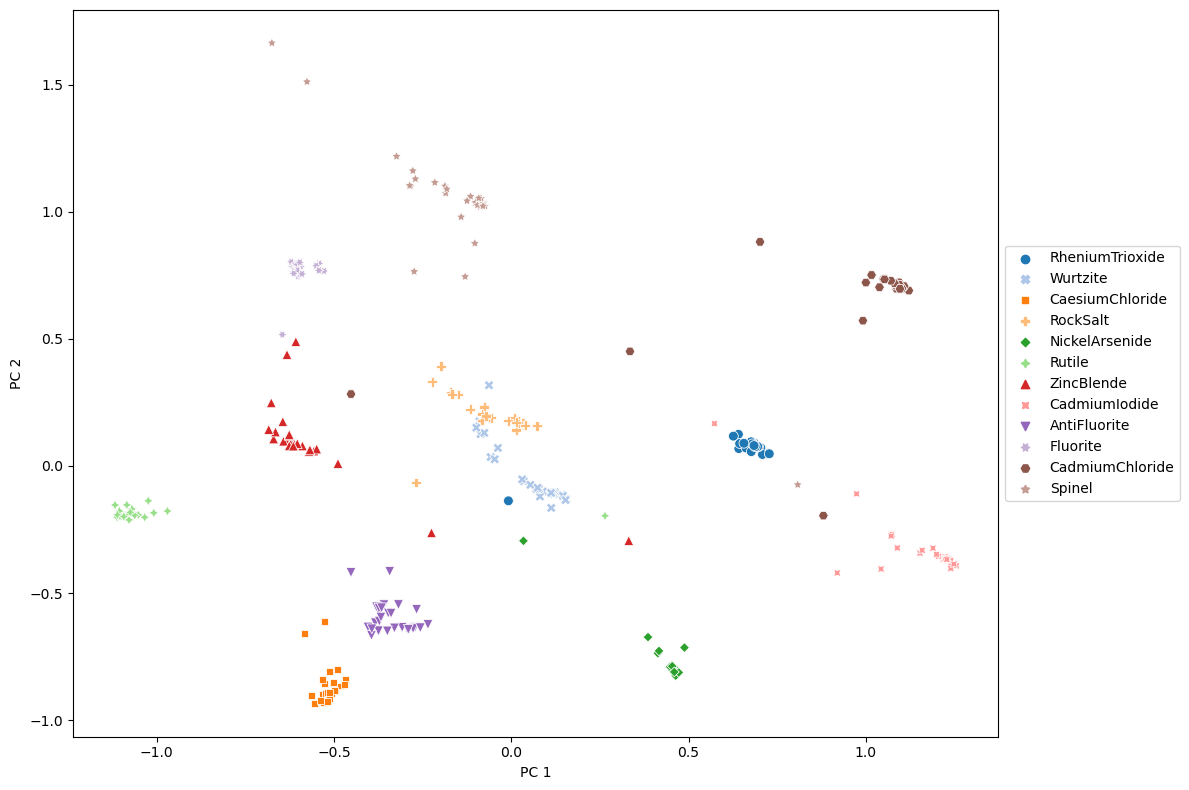

In [ ]:
# Set seaborn style
# sns.set_theme(style='darkgrid', font_scale=1.)
# Make animation of latent space throughout 
# Plot latent space
if len(df_rec['latent_space_mean'].iloc[0]) == 2:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('LS dim 1')
    plt.ylabel('LS dim 2')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='pc1', y='pc2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.show()

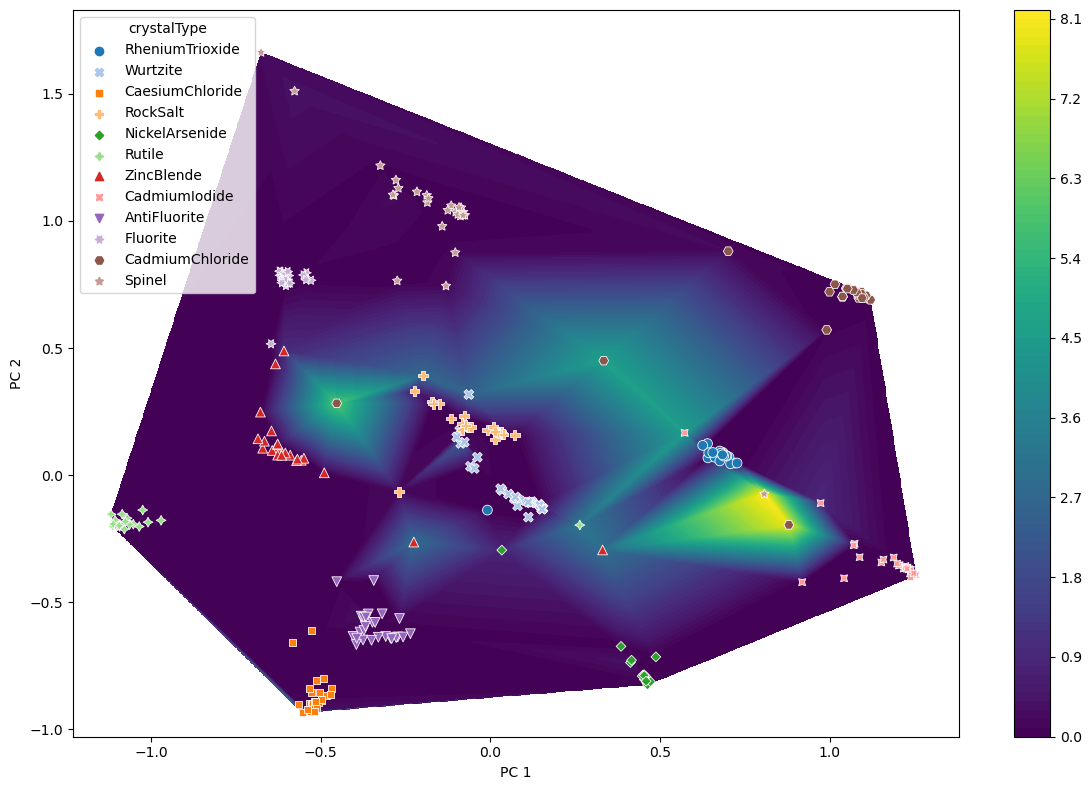

In [11]:
# Plot latent space with surface showing the loss
from scipy.interpolate import griddata
import matplotlib.colors as colors

# Decide on contour column
contour_column = 'reconstruction_loss'

# Get min and max values
min_loss = df_combined[contour_column].min()
max_loss = df_combined[contour_column].max()

# Plot
if len(df_combined['latent_space_mean'].iloc[0]) == 2:
    # Interpolate z values to a grid from points
    xi = np.linspace(df_combined['ls1'].min()*1.1, df_combined['ls1'].max()*1.1, 1000)
    yi = np.linspace(df_combined['ls2'].min()*1.1, df_combined['ls2'].max()*1.1, 1000)
    zi = griddata((df_combined['ls1'], df_combined['ls2']), df_combined[contour_column], (xi[None,:], yi[:,None]), method='linear', fill_value=np.nan)
    
    plt.figure(figsize=(12, 8))
    plt.contourf(xi, yi, zi, 100, cmap='viridis')#, norm=colors.LogNorm())
    sns.scatterplot(data=df_combined, x='ls1', y='ls2', hue='crystalType', style='crystalType', palette='tab20', s=50)
    plt.colorbar()
    plt.xlabel('LS dim 1')
    plt.ylabel('LS dim 2')
    plt.tight_layout()
    plt.show()
else:
    
    # Interpolate z values to a grid from points
    xi = np.linspace(df_combined['pc1'].min()*1.1, df_combined['pc1'].max()*1.1, 1000)
    yi = np.linspace(df_combined['pc2'].min()*1.1, df_combined['pc2'].max()*1.1, 1000)
    zi = griddata((df_combined['pc1'], df_combined['pc2']), df_combined[contour_column], (xi[None,:], yi[:,None]), method='linear', fill_value=np.nan)
    
    plt.figure(figsize=(12, 8))
    plt.contourf(xi, yi, zi, 100, cmap='viridis')#, norm=colors.LogNorm())
    sns.scatterplot(data=df_combined, x='pc1', y='pc2', hue='crystalType', style='crystalType', palette='tab20', s=50)
    plt.colorbar()
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.show()


# Experimental data

## Code

In [12]:
data_folder = './data/Experimental/'

# Load experimental data
data_paths = [str(p) for p in pathlib.Path(data_folder).rglob('*.gr')]

data_filepath = []
data_composition_string = []
data_composition = []
data_pdf = []
for data_path in data_paths:
    with open(data_path, 'r') as f:
        # Load data
        line_counter = 0
        for line in f:
            if line.startswith('composition'):
                composition = ''.join(line.split(' ')[2:])
            if line.startswith('0'):
                header_line = line_counter
                break
            line_counter += 1
    # Remove line breaks
    composition = composition.replace('\n', '')
    
    # Save composition string
    composition_string = deepcopy(composition)

    # Remove stochiometry from composition
    composition = re.sub(r'[0-9\.]+', '', composition)

    # # Split string on capital letters
    composition = re.findall('[A-Z][^A-Z]*', composition)

    # Translate composition to atom numbers
    composition = Atoms(symbols=composition).get_atomic_numbers()
    
    composition_onehot = np.zeros(119)
    composition_onehot[composition] = 1
    
    
    # Load data
    data = pd.read_csv(data_path, sep=' ', skiprows=header_line, names=['r [Å]', 'G(r) [Å⁻²]'])
    
    data_r = np.arange(0,60,0.01)
    data_Gr = np.interp(data_r, data['r [Å]'], data['G(r) [Å⁻²]'], left=0, right=0)
    data_Gr = data_Gr / np.amax(data_Gr)
    
    data_filepath.append(data_path)
    data_composition_string.append(composition_string)
    data_composition.append(composition_onehot)
    data_pdf.append(data_Gr)

# Convert to tensors
data_composition = torch.tensor(data_composition, dtype=torch.long)
data_pdf = torch.tensor(data_pdf, dtype=torch.float32)
data_composition_string_index = torch.tensor(np.arange(len(data_composition_string)))
data_filepath_index = torch.tensor(np.arange(len(data_filepath)))

exp_data = TensorDataset(data_pdf, data_composition, data_composition_string_index, data_filepath_index)

# Dataloader
exp_loader = DataLoader(exp_data, batch_size=10, shuffle=False)

# Results dict
exp_results = {
    'composition': [],
    'pdf': [],
    'prior_mean': [],
    'prior_log_std': [],
    'z_sample': [],
    'cell_parameters': [],
    'cell_positions': [],
    'cell_atoms': [],
}

In [13]:
# Inference
model.eval()
for batch in tqdm(exp_loader, desc='Inference', disable=setup_json['disable_tqdm']):
    this_batch_size = len(batch[0])
    pdf, composition, composition_string_index, filepath_index = batch
    pdf = pdf.unsqueeze(-1).to(device)
    composition = composition.float().to(device)
    
    with torch.no_grad():
        cell_parameters, cell_positions, cell_atoms, prior_mean, prior_log_std, z_sample = model.predict(
            pdf, 
            composition,
        )
    
    # Denormalize cell parameters
    if setup_json['data']['normalize_cell_parameters']:
        cell_parameters = (cell_parameters * cell_stds) + cell_means
    
    # Rounding positions to 5 decimals
    cell_positions = torch.round(cell_positions, decimals=5)
    
    # Store composition
    for index in composition_string_index:
        exp_results['composition'].append(data_composition_string[index])
    
    # Store PDF
    exp_results['pdf'].extend(pdf.cpu().tolist())
    
    # Store latent representation
    exp_results['prior_mean'].extend(prior_mean.cpu().tolist())
    exp_results['prior_log_std'].extend(prior_log_std.cpu().tolist())
    exp_results['z_sample'].extend(z_sample.cpu().tolist())
    
    # Store predictions
    exp_results['cell_parameters'].extend(cell_parameters.cpu().tolist())
    exp_results['cell_positions'].extend(cell_positions.cpu().tolist())
    exp_results['cell_atoms'].extend(torch.argmax(cell_atoms, dim=2).cpu().tolist())
    
    # Create CIF files
    for batch_index in range(this_batch_size):
        # Prediction
        try:
            create_cif(
                cell_params = cell_parameters[batch_index].detach().cpu().numpy(),
                cell_positions = cell_positions[batch_index].detach().cpu().numpy(),
                cell_atoms = cell_atoms[batch_index].detach().cpu().numpy(),
                filename = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/experimental_predictions/{data_filepath[data_filepath_index[batch_index]].split("/")[-1].split(".")[0]}',
                prediction=True,
                composition=data_composition_string[composition_string_index[batch_index]],
                simplified_atom_identities=setup_json['training']['simplified_atom_identities'],
            )
        except:
            print(f'Failed to create CIF file for prediction of {data_composition_string[composition_string_index[batch_index]]}.')
    
df_exp_results = pd.DataFrame(exp_results)
if len(df_exp_results['prior_mean'].iloc[0]) == 2:
    df_exp_results[['ls1', 'ls2']] = df_exp_results['prior_mean'].apply(pd.Series)
else:
    # Perform PCA
    df_exp_results[['pc1', 'pc2']] = pca.transform(np.array(df_exp_results['prior_mean'].values.tolist()))
df_exp_results.head()

# Drop IrO2
# df_exp_results = df_exp_results[df_exp_results['composition'] != 'IrO2']

,composition,pdf,prior_mean,prior_log_std,z_sample,cell_parameters,cell_positions,cell_atoms,pc1,pc2
0,IrO2,"[[0.0], [0.0007761651650071144], [0.0015256106...","[-0.22202804684638977, 0.250118225812912, -0.6...","[0.13615110516548157, 0.16750073432922363, 0.1...","[-0.2205425500869751, 0.1438559889793396, -0.5...","[4.651987552642822, 4.59456205368042, 3.891107...","[[0.03297000005841255, 0.03564000129699707, 0....","[2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",-0.870001,-0.043587
1,IrO2,"[[0.0], [0.0005720379413105547], [0.0011345194...","[-1.0653282403945923, 0.1735631823539734, 0.43...","[0.12169937044382095, 0.15803410112857819, 0.1...","[-0.887866735458374, 0.35036414861679077, 0.38...","[8.18853759765625, 8.23626708984375, 8.2668876...","[[0.5200200080871582, 0.5115100145339966, 0.49...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",-0.207055,1.097543
2,IrO2,"[[0.0], [-0.000292735145194456], [-0.000565890...","[0.03418056666851044, -0.06352287530899048, -0...","[0.12008669972419739, 0.1605658084154129, 0.17...","[0.040143534541130066, -0.06628561019897461, -...","[4.585138320922852, 4.5822062492370605, 3.1689...","[[0.0040799998678267, 0.01827000081539154, 0.0...","[2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, ...",-1.077249,-0.189489
3,CeO2,"[[0.0], [-0.000268803967628628], [-0.000530091...","[-0.4816195070743561, -0.3993668556213379, -0....","[0.16994576156139374, 0.1794666051864624, 0.20...","[-0.032209187746047974, -0.42674288153648376, ...","[5.089138984680176, 5.060916900634766, 5.39156...","[[0.019530000165104866, 0.1444299966096878, -0...","[2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.638522,0.698818
4,CeO2,"[[0.0], [-0.0003009798820130527], [-0.00059319...","[-0.4851948916912079, -0.40248924493789673, -0...","[0.1694910228252411, 0.17872174084186554, 0.20...","[-0.1737287938594818, -0.5779148936271667, -0....","[5.355555534362793, 5.285807132720947, 5.28138...","[[0.008999999612569809, 0.03044000081717968, 0...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.639976,0.703330


## Plot

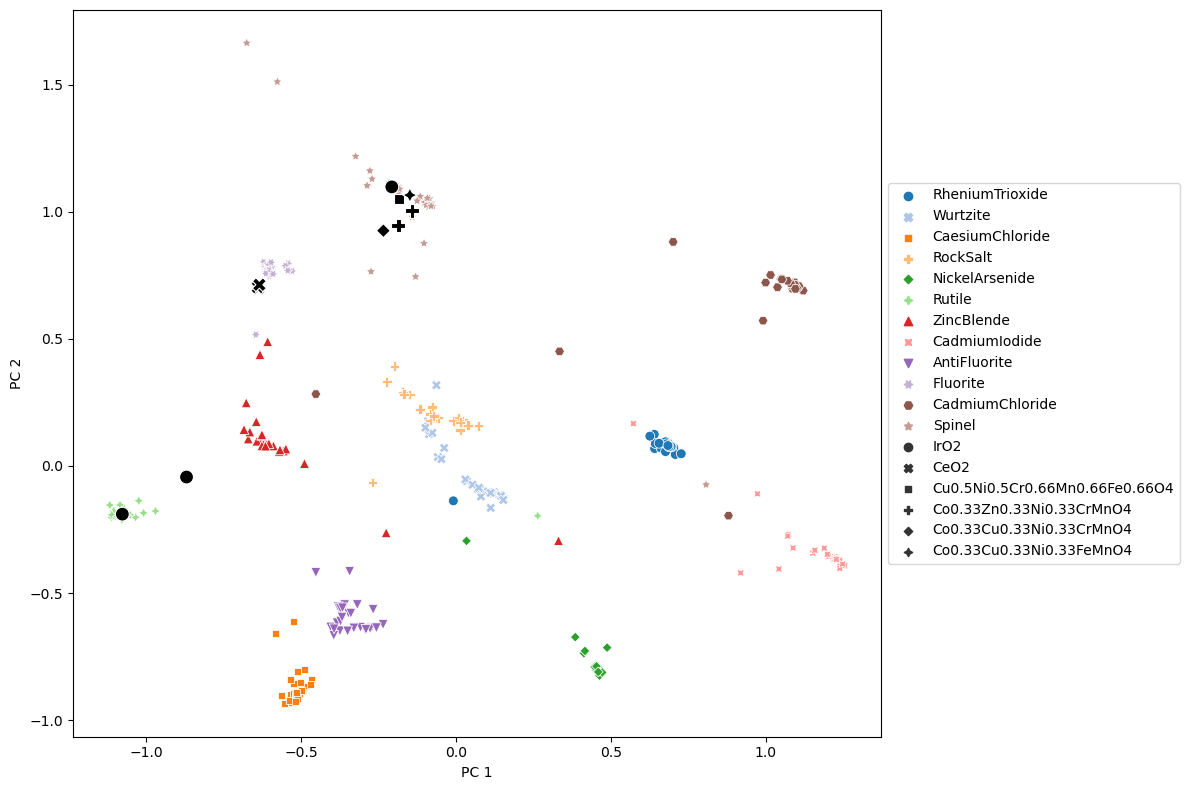

In [14]:
# Plot latent space placement of experimental data
if len(df_rec['latent_space_mean'].iloc[0]) == 2:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    sns.scatterplot(data=df_exp_results, x='ls1', y='ls2', c='black', style='composition', s=100)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('LS dim 1')
    plt.ylabel('LS dim 2')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='pc1', y='pc2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    sns.scatterplot(data=df_exp_results, x='pc1', y='pc2', c='black', style='composition', s=100)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.show()

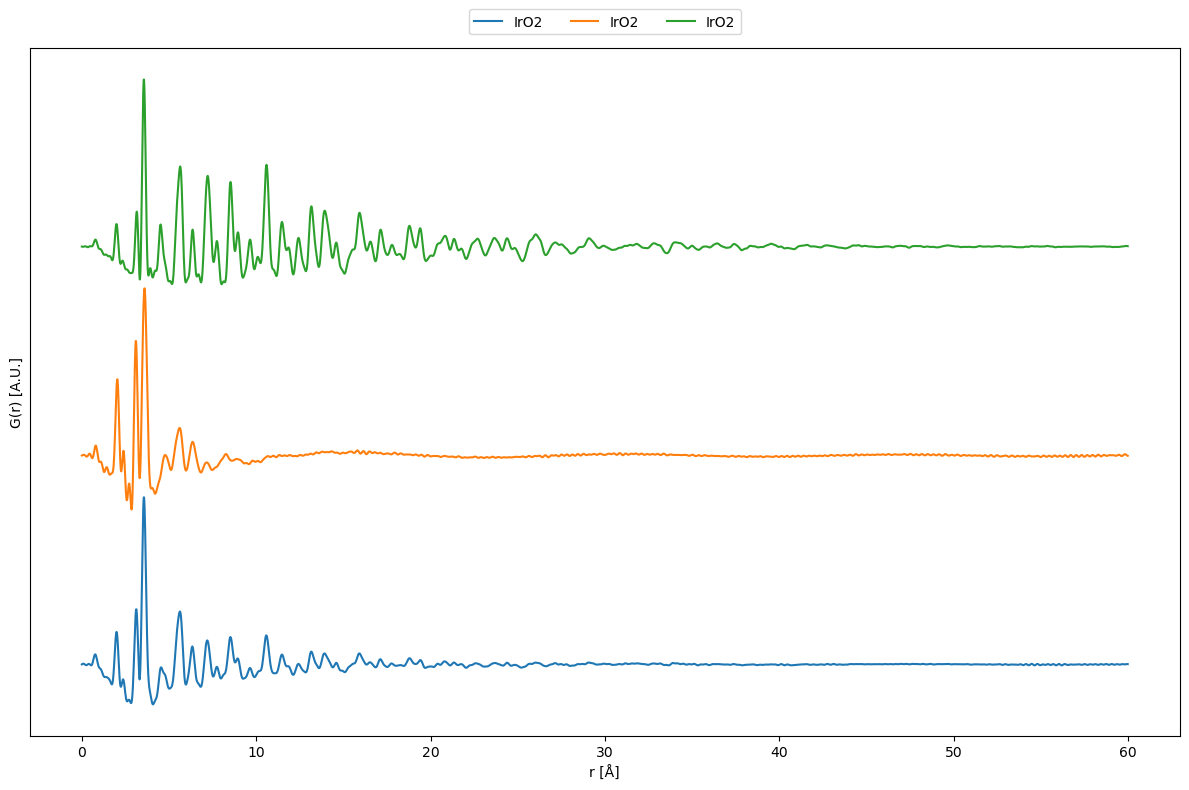

In [15]:
# Plot the experimental data
index_list = [0,1,2]
# index_list = [3, 4, 5]
# index_list = list(range(6,11))

plt.figure(figsize=(12, 8))
for index in index_list:
    plt.plot(np.arange(0,60,0.01), np.array(df_exp_results['pdf'].iloc[index]) + (index * 1.25), label=df_exp_results['composition'].iloc[index])
plt.xlabel('r [Å]')
plt.ylabel('G(r) [A.U.]')
plt.yticks([])
plt.legend(ncols=3, loc='lower center', bbox_to_anchor=(0.5, 1.01))
# plt.title(f'{df_exp_results["composition"].iloc[index]}', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpolate in latent space

## Code

In [25]:
# Create latent samples for interpolation between two points
n_latent_samples = 10

# Define two latent points from pca space
# latent_point_1 = (24, 1) # ex1 (9, -13)
# latent_point_2 = (24, -15) # ex1 (24,-9)

# Define n latent points from latent space
crystal_types = ['CadmiumIodide', 'CadmiumChloride'] #['CadmiumIodide', 'CadmiumChloride'] #['RockSalt', 'Spinel', 'ZincBlende']
indices = [14,3] #[14,3] #[0, 4, 0]
point_indices = [df_rec[(df_rec['crystalType'] == crystal_type)].index[index] for crystal_type, index in zip(crystal_types, indices)]

latent_points = [np.array(df_rec['latent_space_mean'].iloc[point_index]) for point_index in point_indices]

# Interpolation mode flag (True for PCA. False for full latent space)
pca_inter = False

# Define dummy composition
comp = ['Fe', 'O']
comp = Atoms(symbols=comp).get_atomic_numbers()
comp_onehot = torch.zeros(119)
comp_onehot[comp] = 1

# Latent samples are n_latent_samples evenly spaced points between the two points
if pca_inter:
    for i in range(len(latent_points)-1):
        if i == 0:
            interp_pca = np.array([np.linspace(latent_points[i][j], latent_points[i+1][j], n_latent_samples) for j in range(len(latent_points[i]))]).T
        else:
            interp_pca = np.concatenate([interp_pca, np.array([np.linspace(latent_points[i][j], latent_points[i+1][j], n_latent_samples) for j in range(len(latent_points[i]))]).T], axis=0)
    
    if len(df_rec['latent_space_mean'].iloc[0]) > 2:
        interp_latent = pca.inverse_transform(interp_pca)
    else:
        interp_latent = interp_pca
    interp_latent = torch.tensor(interp_latent).float()
else:
    # Transform back to latent dimensions if latent space is more than 2D
    if (len(df_rec['latent_space_mean'].iloc[0]) > 2) and (len(latent_points[0]) == 2):
        latent_points = pca.inverse_transform(latent_points)
    
    for i in range(len(latent_points)-1):
        if i == 0:
            interp_latent = np.array([np.linspace(latent_points[i][j], latent_points[i+1][j], n_latent_samples) for j in range(len(latent_points[i]))]).T
        else:
            interp_latent = np.concatenate([interp_latent, np.array([np.linspace(latent_points[i][j], latent_points[i+1][j], n_latent_samples) for j in range(len(latent_points[i]))]).T], axis=0)
        
    interp_latent = torch.tensor(interp_latent).float()

n_interp_points = interp_latent.shape[0]
interp_index = torch.tensor([i for i in range(n_interp_points)])

# Create dataset
interp_dataset = TensorDataset(interp_latent, interp_index, comp_onehot.repeat(n_interp_points, 1))

# Dataloader
interp_loader = DataLoader(interp_dataset, batch_size=10, shuffle=False)

# Results dict
interp_results = {
    'name': [],
    'latent_point': [],
    'cell_parameters': [],
    'cell_positions': [],
    'cell_atoms': [],
}

In [26]:
# Inference
model.eval()
for batch in tqdm(interp_loader, desc='Interpolating', disable=setup_json['disable_tqdm']):
    this_batch_size = len(batch[0])
    interp_point, interp_index, composition = batch
    interp_point = interp_point.to(device)
    interp_index = interp_index.to(device)
    composition = composition.to(device)
    
    with torch.no_grad():
        cell_parameters, cell_positions, cell_atoms = model.decode(
            interp_point, 
            composition=composition,
        )
    
    # Denormalize cell parameters
    if setup_json['data']['normalize_cell_parameters']:
        cell_parameters = (cell_parameters * cell_stds) + cell_means
    
    # Rounding positions to 5 decimals
    cell_positions = torch.round(cell_positions, decimals=5)
    
    # Store latent points
    interp_results['name'].extend([f'sample_{interp_index[batch_index]}' for batch_index in range(this_batch_size)])
    interp_results['latent_point'].extend(interp_point.cpu().tolist())
    
    # Store predictions
    interp_results['cell_parameters'].extend(cell_parameters.cpu().tolist())
    interp_results['cell_positions'].extend(cell_positions.cpu().tolist())
    interp_results['cell_atoms'].extend(torch.argmax(cell_atoms, dim=2).cpu().tolist())
    
    # Create CIF files
    for batch_index in range(this_batch_size):
        # Prediction
        try:
            create_cif(
                cell_params = cell_parameters[batch_index].detach().cpu().numpy(),
                cell_positions = cell_positions[batch_index].detach().cpu().numpy(),
                cell_atoms = cell_atoms[batch_index].detach().cpu().numpy(),
                filename = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/interpolation_predictions/sample{interp_index[batch_index]}',
                prediction=True,
                composition=None,
                simplified_atom_identities=setup_json['training']['simplified_atom_identities'],
            )
        except:
            print(f'Failed to create CIF file for prediction of sample {interp_index[batch_index]}.')
    

In [27]:
df_interp = pd.DataFrame(interp_results)
if len(df_interp['latent_point'].iloc[0]) == 2:
    df_interp[['ls1', 'ls2']] = df_interp['latent_point'].apply(pd.Series)
else:
    # Perform PCA
    df_interp[['pc1', 'pc2']] = pca.transform(np.array(df_interp['latent_point'].values.tolist()))
df_interp.head()

,name,latent_point,cell_parameters,cell_positions,cell_atoms,pc1,pc2
0,sample_0,"[0.8719437718391418, 0.7855567932128906, 1.152...","[2.886230230331421, 3.0178918838500977, 4.3759...","[[0.0015200000489130616, -0.002169999992474913...","[2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",1.238919,-0.383509
1,sample_1,"[0.774073600769043, 0.7216503024101257, 1.1896...","[2.9163451194763184, 3.031006097793579, 4.3973...","[[-0.0006699999794363976, -0.00771000003442168...","[2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",1.222512,-0.261971
2,sample_2,"[0.6762034296989441, 0.6577437520027161, 1.226...","[2.9580631256103516, 3.062333583831787, 4.4192...","[[-0.0006399999838322401, -0.00637000007554888...","[2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",1.206104,-0.140433
3,sample_3,"[0.5783332586288452, 0.5938372611999512, 1.264...","[3.042226552963257, 3.1121389865875244, 4.8143...","[[0.007170000113546848, 0.011389999650418758, ...","[2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",1.189697,-0.018894
4,sample_4,"[0.48046308755874634, 0.5299307703971863, 1.30...","[3.0992212295532227, 3.136094331741333, 7.1103...","[[0.007230000104755163, -0.01351999957114458, ...","[2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, ...",1.173289,0.102644


## Plot

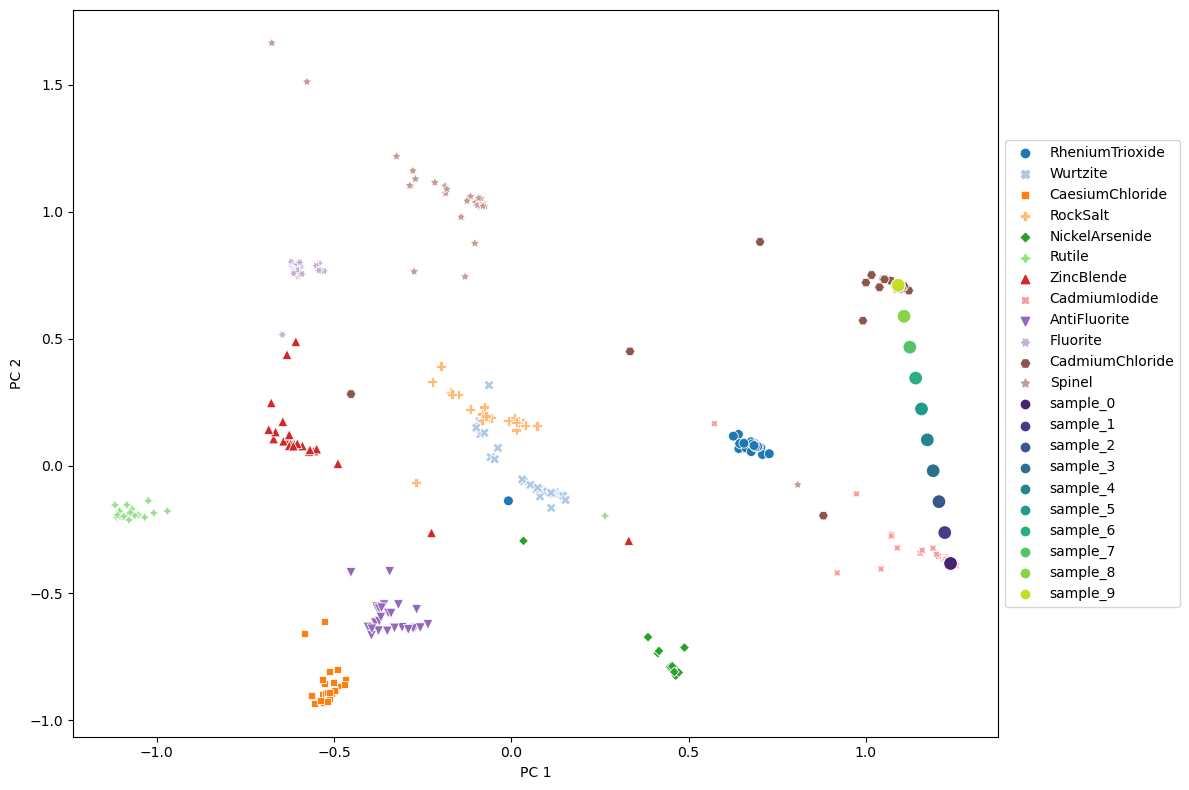

In [28]:
# Plot interpolation results in latent space
if len(df_rec['latent_space_mean'].iloc[0]) == 2:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    sns.scatterplot(data=df_interp, x='ls1', y='ls2', color='black', marker='o', s=100)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('LS dim 1')
    plt.ylabel('LS dim 2')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='pc1', y='pc2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    sns.scatterplot(data=df_interp, x='pc1', y='pc2', hue='name', palette='viridis', marker='o', s=100)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.show()

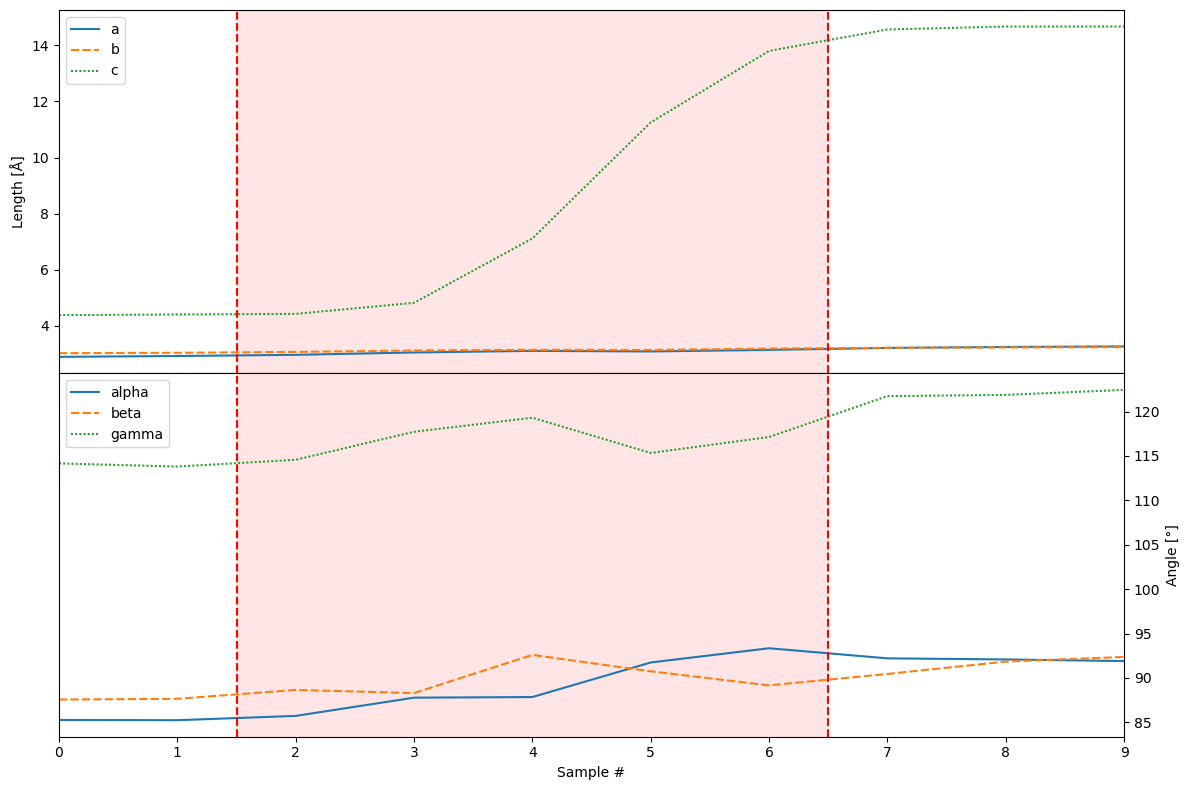

In [29]:
# Plot the cell parameters of the interpolation with angles and lengths on two subplots (one for lengths and one for angles) that share the x-axis
df_cell_params = pd.DataFrame(df_interp['cell_parameters'].tolist(), columns=['a', 'b', 'c', 'alpha', 'beta', 'gamma'])
df_cell_params['name'] = df_interp['name']

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Lengths
sns.lineplot(data=df_cell_params[['a', 'b', 'c']], ax=ax0)
ax0.set_ylabel('Length [Å]')

# Angles
sns.lineplot(data=df_cell_params[['alpha', 'beta', 'gamma']], ax=ax1)
ax1.set_ylabel('Angle [°]')
ax1.set_xlabel('Sample #')
# y-axis label and ticks on the right side
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")

# Add vertical lines for the interpolation outside clusters and color between them
ax0.axvline(x=1.5, color='red', linestyle='--')
ax0.axvline(x=6.5, color='red', linestyle='--')
ax0.axvspan(1.5, 6.5, color='red', alpha=0.1)

ax0.axvline(x=11.5, color='red', linestyle='--')
ax0.axvline(x=16.5, color='red', linestyle='--')
ax0.axvspan(11.5, 16.5, color='red', alpha=0.1)

ax1.axvline(x=1.5, color='red', linestyle='--')
ax1.axvline(x=6.5, color='red', linestyle='--')
ax1.axvspan(1.5, 6.5, color='red', alpha=0.1)

ax1.axvline(x=11.5, color='red', linestyle='--')
ax1.axvline(x=16.5, color='red', linestyle='--')
ax1.axvspan(11.5, 16.5, color='red', alpha=0.1)

plt.xlim(0, n_interp_points-1)

# Make x-ticks integers
plt.xticks(np.arange(0, n_interp_points, 1))

fig.tight_layout()

# Remove space between subplots
plt.subplots_adjust(hspace=0)

plt.show()

# Sample same distribution multiple times

## Code

In [21]:
# Number of samples to generate
n_samples = 100

# Latent distribution to sample from
dist_crystal_type = 'Fluorite'
crystal_type_index = 3
dist_index = df_rec[(df_rec['crystalType'] == dist_crystal_type)].index[crystal_type_index]
dist_mean = df_rec.latent_space_mean.iloc[dist_index]
dist_std = df_rec.latent_space_std.iloc[dist_index]

# Latent distribution from experimental data
# exp_index = 3
# dist_mean = df_exp_results.prior_mean.iloc[exp_index]
# dist_std = df_exp_results.prior_log_std.iloc[exp_index]

latent_dist = torch.distributions.Normal(loc=torch.tensor(dist_mean).float(), scale=torch.tensor(dist_std).float())

# Sample from latent distribution
latent_mean = latent_dist.mean
latent_samples = latent_dist.sample((n_samples,))
# Concatenate with latent mean
latent_samples = torch.cat((latent_mean.unsqueeze(0), latent_samples), dim=0)
sample_index = torch.tensor([i for i in range(n_samples+1)])

# Define dummy composition
comp = ['Fe', 'O']
comp = Atoms(symbols=comp).get_atomic_numbers()
comp_onehot = torch.zeros(119)
comp_onehot[comp] = 1

# Define dataset
sample_dataset = TensorDataset(latent_samples, sample_index, comp_onehot.repeat(n_samples+1, 1))

# Dataloader
sample_loader = DataLoader(sample_dataset, batch_size=10, shuffle=False)

# Results dict
sample_results = {
    'name': [],
    'latent_point': [],
    'cell_parameters': [],
    'cell_positions': [],
    'cell_atoms': [],
}

In [22]:
# Inference
model.eval()
for batch in tqdm(sample_loader, desc='Sampling', disable=setup_json['disable_tqdm']):
    this_batch_size = len(batch[0])
    sample_point, sample_index, composition = batch
    sample_point = sample_point.to(device)
    sample_index = sample_index.to(device)
    composition = composition.to(device)
    
    with torch.no_grad():
        cell_parameters, cell_positions, cell_atoms = model.decode(
            sample_point, 
            composition=composition,
        )
    
    # Denormalize cell parameters
    if setup_json['data']['normalize_cell_parameters']:
        cell_parameters = (cell_parameters * cell_stds) + cell_means
    
    # Rounding positions to 5 decimals
    cell_positions = torch.round(cell_positions, decimals=5)
    
    # Store latent points
    sample_results['name'].extend([f'sample_{sample_index[batch_index]}' for batch_index in range(this_batch_size)])
    sample_results['latent_point'].extend(sample_point.cpu().tolist())
    
    # Store predictions
    sample_results['cell_parameters'].extend(cell_parameters.cpu().tolist())
    sample_results['cell_positions'].extend(cell_positions.cpu().tolist())
    sample_results['cell_atoms'].extend(torch.argmax(cell_atoms, dim=2).cpu().tolist())
    
    # Create CIF files
    for batch_index in range(this_batch_size):
        # Prediction
        try:
            create_cif(
                cell_params = cell_parameters[batch_index].detach().cpu().numpy(),
                cell_positions = cell_positions[batch_index].detach().cpu().numpy(),
                cell_atoms = cell_atoms[batch_index].detach().cpu().numpy(),
                filename = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/sample_predictions/sample{sample_index[batch_index]}',
                prediction=True,
                composition=None,
                simplified_atom_identities=setup_json['training']['simplified_atom_identities'],
            )
        except:
            print(f'Failed to create CIF file for prediction of sample {sample_index[batch_index]}.')

In [23]:
df_sample = pd.DataFrame(sample_results)
if len(df_sample['latent_point'].iloc[0]) == 2:
    df_sample[['ls1', 'ls2']] = df_sample['latent_point'].apply(pd.Series)
else:
    # Perform PCA
    df_sample[['pc1', 'pc2']] = pca.transform(np.array(df_sample['latent_point'].values.tolist()))
    
df_sample['name'][df_sample['name'] == 'sample_0'] = 'Dist. mean'
df_sample.head()

,name,latent_point,cell_parameters,cell_positions,cell_atoms,pc1,pc2
0,Dist. mean,"[-0.49122968316078186, -0.4926779866218567, -0...","[5.386813163757324, 5.298088550567627, 5.27229...","[[0.008870000019669533, 0.012120000086724758, ...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.610088,0.777545
1,sample_1,"[-0.5965352654457092, -0.5581984519958496, -0....","[5.3119611740112305, 5.201942443847656, 5.3037...","[[0.017480000853538513, 0.029179999604821205, ...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.906257,0.774658
2,sample_2,"[-0.4998137354850769, -0.7006860971450806, -0....","[5.339338779449463, 5.258045673370361, 5.20828...","[[0.022430000826716423, 0.01066999975591898, 0...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.761417,0.839617
3,sample_3,"[-0.3682113587856293, -0.363940954208374, -0.0...","[5.432641506195068, 5.354896068572998, 5.40176...","[[-0.0030799999367445707, 0.016140000894665718...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.616473,0.582757
4,sample_4,"[-0.46410199999809265, -0.49155375361442566, 0...","[5.399107933044434, 5.314748764038086, 5.24973...","[[0.007379999849945307, 0.015119999647140503, ...","[2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, ...",-0.549464,0.780397


## Plot

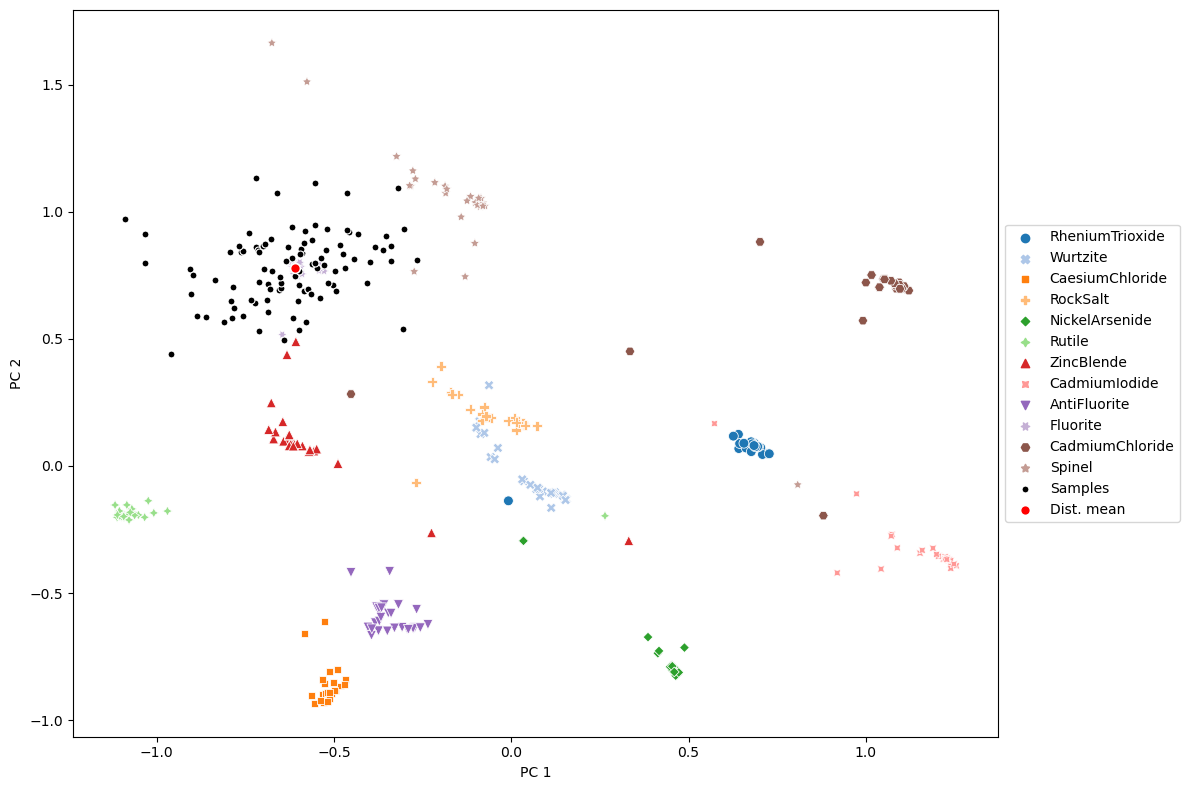

In [24]:
# Plot sampling results in latent space
if len(df_rec['latent_space_mean'].iloc[0]) == 2:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    sns.scatterplot(data=df_sample[df_sample['name'] != 'Dist. mean'], x='ls1', y='ls2', color='black', marker='.', s=100, label='Samples')
    sns.scatterplot(data=df_sample[df_sample['name'] == 'Dist. mean'], x='ls1', y='ls2', color='red', marker='.', s=200, label='Dist. mean')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('LS dim 1')
    plt.ylabel('LS dim 2')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_rec, x='pc1', y='pc2', hue='crystalType', style='crystalType', s=50, palette='tab20')
    # sns.scatterplot(data=df_sample, x='pc1', y='pc2', hue='name', palette='viridis', marker='o', s=100)
    sns.scatterplot(data=df_sample[df_sample['name'] != 'Dist. mean'], x='pc1', y='pc2', color='black', marker='.', s=100, label='Samples')
    sns.scatterplot(data=df_sample[df_sample['name'] == 'Dist. mean'], x='pc1', y='pc2', color='red', marker='.', s=200, label='Dist. mean')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.show()